# UK Company Dissolution Predictor
## Exploratory Data Analysis & Feature Engineering

This notebook explores the dataset collected in `ch_pipeline.ipynb`, 
identifies data quality issues, engineers features, and prepares a 
clean dataset ready for machine learning.

### Objectives
1. Understand the distribution of features and the target variable
2. Identify and handle missing values
3. Detect and cap outliers
4. Remove redundant correlated features
5. Encode categorical variables
6. Save a clean ML-ready dataset

---
**Input:** `companies_dataset.csv`: 800 companies, 26 raw features  
**Output:** `companies_ml.csv`: 800 companies, 42 ML-ready features

## 1. Setup

Import the standard libraries. `matplotlib` and `seaborn` 
are used for visualisation throughout the notebook.

In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [53]:
df = pd.read_csv(r"C:\Users\hp\Desktop\companies_house_ds\companies_dataset.csv")
print(df.shape)
print(df.head())

(800, 26)
  company_number company_status  \
0       NI039509         active   
1       NI038794         active   
2       NI043769         active   
3       NI047536         active   
4       NI050108         active   

                                    company_type incorporation_date  \
0  private-limited-guarant-nsc-limited-exemption         2000-10-25   
1                                            ltd         2000-06-15   
2                                            ltd         2002-08-01   
3                                            ltd         2003-08-12   
4                                            ltd         2004-03-30   

  dissolution_date  age_days  sic_primary               sic_sector  \
0              NaN      9326      88990.0  Public/Education/Health   
1       2013-01-04      4586       4521.0            Manufacturing   
2       2013-10-10      4088       7415.0            Manufacturing   
3       2013-11-08      3741      43390.0   Construction/Transport   
4 

In [54]:
print("Class balance:")
print(df["dissolved"].value_counts())

print("\nMissing values:")
print(df.isnull().sum())

print("\nCompany types:")
print(df["company_type"].value_counts())

Class balance:
dissolved
0    400
1    400
Name: count, dtype: int64

Missing values:
company_number                0
company_status                0
company_type                  0
incorporation_date            0
dissolution_date            299
age_days                      0
sic_primary                 353
sic_sector                    0
region                        0
has_insolvency_history        0
has_charges                   0
has_been_liquidated           0
office_in_dispute             0
undeliverable_address         0
officer_count                 0
resigned_count                0
officer_turnover_rate         0
filing_count                  0
accounts_count                0
confirmation_count            0
charge_count                  0
outstanding_charges           0
charge_satisfaction_rate      0
psc_count                     0
corporate_psc_count           0
dissolved                     0
dtype: int64

Company types:
company_type
ltd                                     

In [55]:
print("SIC missing by status:")
print(df.groupby("dissolved")["sic_primary"].apply(lambda x: x.isnull().sum()))

print("\nRegion distribution:")
print(df["region"].value_counts().head(10))

print("\nNumeric summary:")
print(df.describe())

SIC missing by status:
dissolved
0    292
1     61
Name: sic_primary, dtype: int64

Region distribution:
region
Belfast          148
County Down       68
Edinburgh         56
Co Down           40
Unknown           30
London            27
Antrim            27
County Antrim     20
Co Antrim         18
Co Tyrone         14
Name: count, dtype: int64

Numeric summary:
          age_days   sic_primary  has_insolvency_history  has_charges  \
count   800.000000    447.000000              800.000000    800.00000   
mean   4299.712500  58861.378076                0.131250      0.16250   
std    2584.052071  25842.939930                0.337885      0.36914   
min     229.000000   1130.000000                0.000000      0.00000   
25%    2346.000000  41202.000000                0.000000      0.00000   
50%    3736.000000  62012.000000                0.000000      0.00000   
75%    6072.250000  77749.500000                0.000000      0.00000   
max    9612.000000  99999.000000                1.

In [56]:
# Plot styling
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
sns.set_palette("Set2")

df = pd.read_csv(r"C:\Users\hp\Desktop\companies_house_ds\companies_dataset.csv")
print(f"Dataset: {df.shape[0]} rows, {df.shape[1]} columns")
df.head()

Dataset: 800 rows, 26 columns


,company_number,company_status,company_type,incorporation_date,dissolution_date,age_days,sic_primary,sic_sector,region,has_insolvency_history,...,officer_turnover_rate,filing_count,accounts_count,confirmation_count,charge_count,outstanding_charges,charge_satisfaction_rate,psc_count,corporate_psc_count,dissolved
0,NI039509,active,private-limited-guarant-nsc-limited-exemption,2000-10-25,NaN,9326,88990.0,Public/Education/Health,Newtownabbey,0,...,0.929,85,21,21,0,0,0.000,0,0,0
1,NI038794,active,ltd,2000-06-15,2013-01-04,4586,4521.0,Manufacturing,Carrickfergus,0,...,0.500,43,11,11,1,1,0.000,0,0,0
2,NI043769,active,ltd,2002-08-01,2013-10-10,4088,7415.0,Manufacturing,Co Down,1,...,0.500,59,8,8,3,1,0.667,0,0,0
3,NI047536,active,ltd,2003-08-12,2013-11-08,3741,43390.0,Construction/Transport,County Antrim,0,...,0.000,35,10,9,1,1,0.000,0,0,0
4,NI050108,active,ltd,2004-03-30,2016-06-28,4473,70229.0,Real Estate/Business,Belfast,0,...,0.000,37,12,11,0,0,0.000,0,0,0


## 2. Target Variable

Before exploring features, the class balance of our target 
variable was verified. `dissolved` (1 = dissolved, 0 = active).

A balanced dataset means we do not need to apply resampling techniques 
such as SMOTE, which significantly simplifies the 
modelling process.

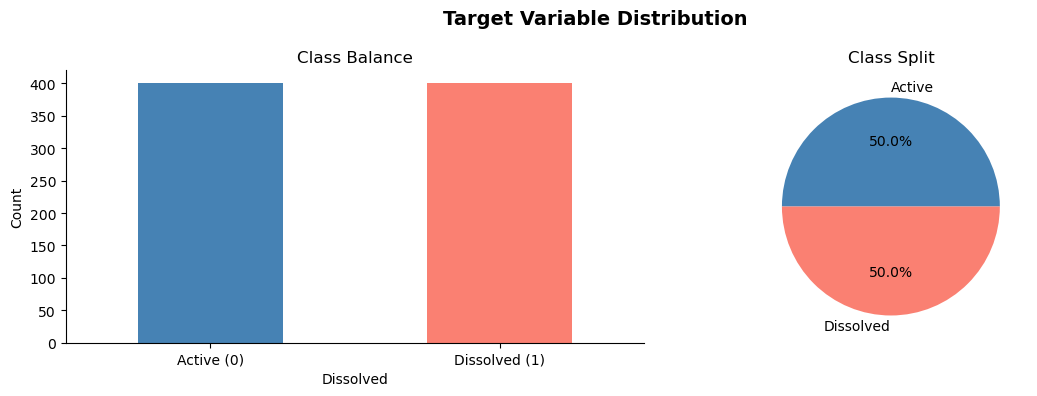

dissolved
0    400
1    400
Name: count, dtype: int64

Balance ratio: 0.50


In [59]:
# 1. Class Balance
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
df["dissolved"].value_counts().plot(kind="bar", ax=axes[0], color=["steelblue", "salmon"])
axes[0].set_title("Class Balance")
axes[0].set_xlabel("Dissolved")
axes[0].set_ylabel("Count")
axes[0].set_xticklabels(["Active (0)", "Dissolved (1)"], rotation=0)

# Pie chart
df["dissolved"].value_counts().plot(kind="pie", ax=axes[1], 
    labels=["Active", "Dissolved"], autopct="%1.1f%%", colors=["steelblue", "salmon"])
axes[1].set_ylabel("")
axes[1].set_title("Class Split")

plt.suptitle("Target Variable Distribution", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(r"C:\Users\hp\Desktop\companies_house_ds\class_balance.png", dpi=150)
plt.show()

print(df["dissolved"].value_counts())
print(f"\nBalance ratio: {df['dissolved'].mean():.2f}")

### Finding
The dataset is perfectly balanced with 400 active and 400 dissolved 
companies (50/50 split). This was achieved by deliberately sampling 
equal numbers of each class during data collection.

## 3. Missing Value Analysis

Identified columns with missing data before deciding how to handle them. 
Different columns require different strategies depending on why the data 
is missing.

In [ ]:
# 2. Missing Values
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.barh(missing.index, missing.values, color="salmon")
ax.bar_label(bars, padding=3)
ax.set_xlabel("Missing Count")
ax.set_title("Missing Values by Column", fontweight="bold")
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(r"C:\Users\hp\Desktop\companies_house_ds\missing_values.png", dpi=150)
plt.show()

# Show missing as percentage
print("Missing values as % of dataset:")
print((missing / len(df) * 100).round(1).to_string())

### Findings

| Column | Missing | Reason | Strategy |
|---|---|---|---|
| `sic_primary` | 44.1% | Not all companies register an industry code | Fill with 0, add `sic_missing` flag |
| `dissolution_date` | 37.4% | Active companies have no dissolution date | Expected — drop column |

The `sic_missing` flag preserves the information that a SIC code was 
absent, which may itself be predictive. 

## 4. Data Cleaning

Applied four cleaning steps:
1. Handle missing SIC codes with a flag column
2. Drop date columns already captured by `age_days`
3. Standardise inconsistent region labels
4. Drop columns not useful for modelling

In [ ]:
# 3. Clean the Data

# 1. sic_primary — fill missing with 0, add a flag column
df["sic_missing"] = df["sic_primary"].isnull().astype(int)
df["sic_primary"] = df["sic_primary"].fillna(0)

# 2. dissolution_date — missing means active, drop the column
df = df.drop(columns=["dissolution_date", "incorporation_date"])

# 3. Clean up region duplicates (Belfast area has multiple labels)
region_map = {
    "Co Down": "County Down",
    "Co Antrim": "County Antrim", 
    "Co Tyrone": "County Tyrone",
    "Co Armagh": "County Armagh",
    "Co Londonderry": "County Londonderry",
    "Co Fermanagh": "County Fermanagh",
}
df["region"] = df["region"].replace(region_map)

# 4. Drop columns not useful for modelling
df = df.drop(columns=["company_number", "company_status", "sic_primary"])

print("Cleaned dataset shape:", df.shape)
print("\nRemaining missing values:", df.isnull().sum().sum())
print("\nColumns:", list(df.columns))

## 5. Feature Distributions

Plotted the distribution of each numeric feature split by class 
(active vs dissolved). This reveals which features differ meaningfully 
between the two classes and are likely to be useful predictors.

**Colour coding:** Blue = Active, Red = Dissolved

In [ ]:
# 4. Numeric Feature Distributions
numeric_cols = [
    "age_days", "officer_count", "resigned_count", "officer_turnover_rate",
    "filing_count", "accounts_count", "confirmation_count", "charge_count",
    "outstanding_charges", "charge_satisfaction_rate", "psc_count", "corporate_psc_count"
]

fig, axes = plt.subplots(4, 3, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].hist(df[df["dissolved"]==0][col], bins=30, alpha=0.6, 
                 color="steelblue", label="Active")
    axes[i].hist(df[df["dissolved"]==1][col], bins=30, alpha=0.6, 
                 color="salmon", label="Dissolved")
    axes[i].set_title(col)
    axes[i].legend(fontsize=8)

plt.suptitle("Feature Distributions: Active vs Dissolved", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(r"C:\Users\hp\Desktop\companies_house_ds\feature_distributions.png", dpi=150)
plt.show()

### Findings

| Feature | Observation |
|---|---|
| `age_days` | Dissolved companies skew younger — active companies have a wider spread |
| `filing_count` | Dissolved companies filed significantly less on average |
| `officer_turnover_rate` | Active companies cluster near 0, dissolved companies more spread |
| `charge_count` | Dissolved companies have notably more charges |
| `psc_count` | Very similar distributions — likely a weak predictor |

In [ ]:
# 6. Cap Outliers
cap_cols = {
    "officer_count": 20,
    "resigned_count": 20,
    "filing_count": 60,
    "accounts_count": 20,
    "confirmation_count": 20,
    "charge_count": 10,
    "outstanding_charges": 10,
}

for col, cap in cap_cols.items():
    df[col] = df[col].clip(upper=cap)

print("Outliers capped.")
print(df[list(cap_cols.keys())].describe().loc[["max"]].round(1))

## 6. Outlier Detection

Boxplots reveal extreme values that could distort model training. 
Identifed columns where outliers are present and applied capping 
(winsorisation) to reduce their influence without removing data points.

In [ ]:
# 5. Boxplots
fig, axes = plt.subplots(3, 4, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    df.boxplot(column=col, by="dissolved", ax=axes[i], 
               boxprops=dict(color="steelblue"),
               medianprops=dict(color="red"))
    axes[i].set_title(col)
    axes[i].set_xlabel("Dissolved")

plt.suptitle("Outliers by Feature: Active vs Dissolved", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(r"C:\Users\hp\Desktop\companies_house_ds\boxplots.png", dpi=150)
plt.show()

### Findings
Several features contain extreme outliers — `officer_count` reaches 100 
and `filing_count` reaches 100. These likely represent unusually large 
or long-lived companies. We cap these at sensible upper limits based 
on the interquartile range to prevent them dominating the model.

## 7. Correlation Analysis

We compute pairwise correlations between all numeric features. This serves 
two purposes:

1. **Identify predictive features** — features strongly correlated with 
`dissolved` are likely useful for the model
2. **Identify multicollinearity** — features highly correlated with each 
other carry redundant information and one of each pair should be removed

In [ ]:
# 7. Correlation Heatmap
numeric_df = df.select_dtypes(include="number")

fig, ax = plt.subplots(figsize=(14, 10))
corr = numeric_df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))  # hide upper triangle

sns.heatmap(
    corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
    center=0, linewidths=0.5, ax=ax, annot_kws={"size": 8}
)
ax.set_title("Feature Correlation Matrix", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(r"C:\Users\hp\Desktop\companies_house_ds\correlation_heatmap.png", dpi=150)
plt.show()

### Findings

**Strongest correlations with `dissolved`:**

| Feature | Correlation | Interpretation |
|---|---|---|
| `sic_missing` | -0.58 | Missing SIC strongly predicts active status |
| `filing_count` | +0.54 | More filings associated with dissolution |
| `accounts_count` | +0.53 | More accounts filed associated with dissolution |
| `undeliverable_address` | -0.39 | Undeliverable address predicts active status |
| `officer_turnover_rate` | +0.40 | Higher turnover associated with dissolution |

**Multicollinearity identified:**

| Pair | Correlation | Action |
|---|---|---|
| `accounts_count` & `confirmation_count` | 0.97 | Drop `confirmation_count` |
| `officer_count` & `resigned_count` | 0.93 | Drop `resigned_count` |
| `filing_count` & `accounts_count` | 0.92 | Drop `accounts_count` |

In [ ]:
# 8. Drop Highly Correlated Features
# Keep the more interpretable of each correlated pair
df = df.drop(columns=["confirmation_count", "resigned_count", "accounts_count"])

print("Remaining columns:", list(df.columns))
print("Shape:", df.shape)

## 8. Categorical Feature Analysis

Examined how dissolution rates vary across categorical features i.e 
company type and industry sector. This helps to determine whether 
these categories carry are meaningful for the model.

In [ ]:
# 9. Categorical Feature Analysis
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Company type vs dissolution rate
type_dissolve = df.groupby("company_type")["dissolved"].mean().sort_values(ascending=False)
type_dissolve.plot(kind="bar", ax=axes[0], color="steelblue")
axes[0].set_title("Dissolution Rate by Company Type", fontweight="bold")
axes[0].set_ylabel("Dissolution Rate")
axes[0].set_xlabel("")
axes[0].tick_params(axis="x", rotation=45)

# SIC sector vs dissolution rate
sector_dissolve = df.groupby("sic_sector")["dissolved"].mean().sort_values(ascending=False)
sector_dissolve.plot(kind="bar", ax=axes[1], color="salmon")
axes[1].set_title("Dissolution Rate by SIC Sector", fontweight="bold")
axes[1].set_ylabel("Dissolution Rate")
axes[1].set_xlabel("")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.savefig(r"C:\Users\hp\Desktop\companies_house_ds\categorical_features.png", dpi=150)
plt.show()

### Findings

**Company type** shows strong variation in dissolution rates:
- `limited-partnership` and `llp` have near 0% dissolution in this sample
- `private-limited-guarant-nsc` types show ~80-90% dissolution rates
- Standard `ltd` companies sit at ~33%

**SIC sector** also varies considerably:
- Companies with unknown SIC codes show only ~17% dissolution which is 
consistent with `sic_missing` being a strong negative predictor
- Most sectors with known SIC codes show 60-85% dissolution rates

These patterns confirm both features will add value to the model.

## 9. Region Cleaning

The raw region field contains over 140 unique values due to inconsistent 
formatting e.g `Co Antrim`, `Co. Antrim`, `Co.Antrim` and 
`County Antrim` all refer to the same place.

These were consolidated into 13 meaningful geographic buckets using a 
rule-based mapping function.

In [ ]:
# 10. Encode Categoricals
from sklearn.preprocessing import LabelEncoder

# One-hot encode company_type and sic_sector
df_ml = pd.get_dummies(df, columns=["company_type", "sic_sector", "region"], 
                        drop_first=True)

print("ML-ready shape:", df_ml.shape)
print("Columns:", list(df_ml.columns))

# Save ML-ready dataset
df_ml.to_csv(r"C:\Users\hp\Desktop\companies_house_ds\companies_ml.csv", index=False)
print("\nSaved companies_ml.csv")

In [ ]:
# Fix Region
# Reload the pre-encoded df (before get_dummies)
df_clean = pd.read_csv(r"C:\Users\hp\Desktop\companies_house_ds\companies_dataset.csv")

# Redo the cleaning steps
df_clean["sic_missing"] = df_clean["sic_primary"].isnull().astype(int)
df_clean["sic_primary"] = df_clean["sic_primary"].fillna(0)
df_clean = df_clean.drop(columns=["dissolution_date", "incorporation_date", 
                                   "company_number", "company_status", "sic_primary",
                                   "confirmation_count", "resigned_count", "accounts_count"])

# Clean regions and place into buckets
def clean_region(r):
    r = str(r).lower().strip().replace("co.", "county").replace("co ", "county ")
    if any(x in r for x in ["antrim", "belfast", "ballymena", "ballyclare", 
                              "carrickfergus", "larne", "newtownabbey"]):
        return "County Antrim"
    if any(x in r for x in ["down", "bangor", "newry", "carryduff", "holywood"]):
        return "County Down"
    if any(x in r for x in ["londonderry", "derry", "coleraine", "limavady", "magherafelt"]):
        return "County Londonderry"
    if any(x in r for x in ["tyrone", "omagh", "dungannon", "cookstown", "strabane"]):
        return "County Tyrone"
    if any(x in r for x in ["armagh", "portadown", "craigavon", "banbridge"]):
        return "County Armagh"
    if any(x in r for x in ["fermanagh", "enniskillen"]):
        return "County Fermanagh"
    if any(x in r for x in ["edinburgh", "glasgow", "scotland", "aberdeen", 
                              "midlothian", "ayr", "perthshire"]):
        return "Scotland"
    if any(x in r for x in ["london", "essex", "kent", "surrey", "middlesex",
                              "hertfordshire", "berkshire", "buckinghamshire"]):
        return "London/SE England"
    if any(x in r for x in ["manchester", "lancashire", "yorkshire", "merseyside",
                              "birmingham", "midlands", "cheshire"]):
        return "England Other"
    if any(x in r for x in ["wales", "cardiff", "swansea", "cwmbran"]):
        return "Wales"
    if any(x in r for x in ["usa", "canada", "netherlands", "norway", 
                              "south africa", "jersey", "guernsey", "isle of man",
                              "channel islands", "british virgin"]):
        return "International"
    if "unknown" in r or "northern ireland" in r or "n ireland" in r or "n. ireland" in r:
        return "Unknown/NI"
    return "Other"

df_clean["region_clean"] = df_clean["region"].apply(clean_region)

print("Region distribution after cleaning:")
print(df_clean["region_clean"].value_counts())
print(f"\nUnique regions: {df_clean['region_clean'].nunique()}")

## 10. Encoding and Final Dataset

Applied one-hot encoding to the three remaining categorical features:
- `company_type` — 7 categories
- `sic_sector` — 9 categories  
- `region_clean` — 13 categories

`drop_first=True` removes one category per feature to avoid the 
dummy variable trap (perfect multicollinearity).

In [ ]:
# Re-encode and save ML Dataset
df_clean = df_clean.drop(columns=["region"])

df_ml = pd.get_dummies(df_clean, columns=["company_type", "sic_sector", "region_clean"],
                        drop_first=True)

print("Final ML-ready shape:", df_ml.shape)
print("\nColumns:", list(df_ml.columns))

# Save
df_ml.to_csv(r"C:\Users\hp\Desktop\companies_house_ds\companies_ml.csv", index=False)
print("\nSaved companies_ml.csv")

In [ ]:
# 11. EDA Summary
summary = {
    "Total companies": len(df),
    "Active": (df["dissolved"] == 0).sum(),
    "Dissolved": (df["dissolved"] == 1).sum(),
    "Features after cleaning": df.shape[1] - 1,
    "Strongest predictors": [
        "sic_missing (-0.58)",
        "filing_count (0.54)",
        "accounts_count (0.53)", 
        "undeliverable_address (-0.39)",
        "officer_turnover_rate (0.40)"
    ],
    "Multicollinearity removed": [
        "confirmation_count",
        "resigned_count", 
        "accounts_count"
    ]
}

for k, v in summary.items():
    print(f"{k}: {v}")

## Summary

### What we started with
- 800 companies, 26 raw features
- Messy region labels, missing SIC codes, correlated features, outliers

### What we produced
- 800 companies, 42 clean ML-ready features
- Zero missing values
- Capped outliers
- Consolidated regions (140+ → 13 buckets)
- Removed 3 redundant correlated features
- Added `sic_missing` flag

### Key findings
- Perfect 50/50 class balance. No resampling needed
- `sic_missing`, `filing_count` and `officer_turnover_rate` are the 
strongest predictors of dissolution
- Company type and region carry meaningful signal
- PSC features are likely weak predictors

*Next: Open `ch_Modelling.ipynb` for training and evaluation of ML models notebook.*